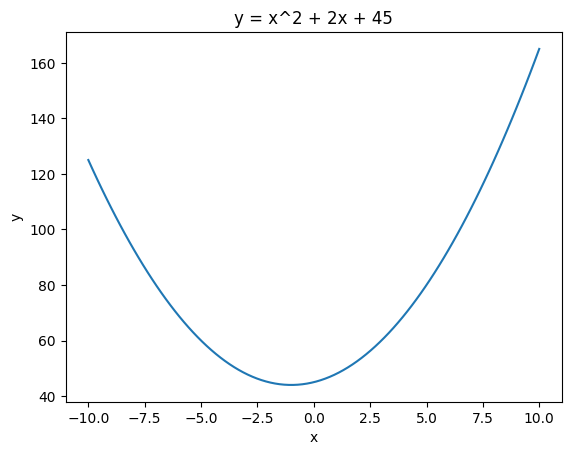

In [1]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-10, 10, 100)
y = x**2 + 2*x + 45

plt.plot(x.numpy(), y.numpy())
plt.title("y = x^2 + 2x + 45")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [4]:
import torch

# Create two 2D tensors (matrices)
# Matrix A: Shape (2, 3)
matrix_a = torch.tensor([[1, 2, 3], 
                         [4, 5, 6]])

# Matrix B: Shape (3, 2)
matrix_b = torch.tensor([[7, 8], 
                         [34, 10], 
                         [11, 12]])

# Method 1: Using the @ operator (cleanest)
result_at = matrix_a @ matrix_b

# Method 2: Using torch.matmul()
result_matmul = torch.matmul(matrix_a, matrix_b)

# Method 3: Using torch.mm() (specifically for 2D matrices only)
result_mm = torch.mm(matrix_a, matrix_b)

print("Matrix A shape:", matrix_a.shape)
print("Matrix B shape:", matrix_b.shape)
print("\nResult of multiplication:\n", result_at)
print("Result shape:", result_at.shape)

Matrix A shape: torch.Size([2, 3])
Matrix B shape: torch.Size([3, 2])

Result of multiplication:
 tensor([[108,  64],
        [264, 154]])
Result shape: torch.Size([2, 2])


In [1]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)

lol()
  

-3.9999999999995595
